<b><h3><center>`Delinquecy Prediction`

<b>Introduction

In today’s financial industry, predicting customer delinquency is crucial for effective risk management and decision-making. This dataset captures financial, credit, and behavioral information of customers, enabling organizations to assess the likelihood of loan defaults or missed payments. By analyzing patterns in credit utilization, payment history, income, and employment status, predictive models can identify high-risk customers and help financial institutions take proactive measures.

<b>Problem Statement

Financial institutions face significant challenges in managing credit risk and minimizing loan defaults. The primary goal of this dataset is to predict whether a customer is likely to have a delinquent account based on their financial history, credit utilization, employment status, and recent payment behavior.

By analyzing this data, we aim to:

Identify high-risk customers before defaults occur.

Understand the key factors contributing to delinquency.

Enable banks and lenders to make informed decisions regarding loan approvals, credit limits, and risk mitigation strategies.

The prediction task can be approached as a binary classification problem, where the target variable is Delinquent_Account (0 = No, 1 = Yes).

<b>Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

<b>Load dataset

In [2]:
df=pd.read_csv("C:/Users/om/Downloads/Delinquency_prediction_dataset.csv")

In [3]:
df.head()

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Employment_Status,Account_Tenure,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
0,CUST0001,56,165580.0,398.0,0.39,3,0,16310.0,0.32,EMP,18,Student,Los Angeles,Late,Late,Missed,Late,Missed,Late
1,CUST0002,69,100999.0,493.0,0.31,6,1,17401.0,0.20,Self-employed,0,Standard,Phoenix,Missed,Missed,Late,Missed,On-time,On-time
2,CUST0003,46,188416.0,500.0,0.36,0,0,13761.0,0.30,Self-employed,1,Platinum,Chicago,Missed,Late,Late,On-time,Missed,Late
3,CUST0004,32,101672.0,413.0,0.37,3,0,88778.0,0.26,Unemployed,15,Platinum,Phoenix,Late,Missed,Late,Missed,Late,Late
4,CUST0005,60,38524.0,487.0,0.23,2,0,13316.0,0.51,Self-employed,11,Standard,Phoenix,Missed,On-time,Missed,Late,Late,Late


<b>Dataset Overview

This dataset contains financial and behavioral attributes of customers. It is used to predict delinquency risk
based on past financial activities, credit history, and employment status. Below is a detailed explanation of
each column.


In [4]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 500
Number of columns: 19


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           500 non-null    object 
 1   Age                   500 non-null    int64  
 2   Income                461 non-null    float64
 3   Credit_Score          498 non-null    float64
 4   Credit_Utilization    500 non-null    float64
 5   Missed_Payments       500 non-null    int64  
 6   Delinquent_Account    500 non-null    int64  
 7   Loan_Balance          471 non-null    float64
 8   Debt_to_Income_Ratio  500 non-null    float64
 9   Employment_Status     500 non-null    object 
 10  Account_Tenure        500 non-null    int64  
 11  Credit_Card_Type      500 non-null    object 
 12  Location              500 non-null    object 
 13  Month_1               500 non-null    object 
 14  Month_2               500 non-null    object 
 15  Month_3               5

<b>Statistical values of all numeric Data type

In [6]:
df.describe()

,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure
count,500.000000,461.000000,498.000000,500.000000,500.000000,500.000000,471.000000,500.00000,500.000000
mean,46.266000,108379.893709,577.716867,0.491620,2.968000,0.160000,48654.428875,0.29866,9.740000
std,16.187629,53662.723741,168.881211,0.197211,1.946935,0.366973,29395.537273,0.09461,5.923054
min,18.000000,15404.000000,301.000000,0.050000,0.000000,0.000000,612.000000,0.10000,0.000000
25%,33.000000,62295.000000,418.250000,0.360000,1.000000,0.000000,23716.500000,0.23000,5.000000
50%,46.500000,107658.000000,586.000000,0.490000,3.000000,0.000000,45776.000000,0.30000,10.000000
75%,59.250000,155734.000000,727.250000,0.630000,5.000000,0.000000,75546.500000,0.36000,15.000000
max,74.000000,199943.000000,847.000000,1.030000,6.000000,1.000000,99620.000000,0.55000,19.000000


Categorical Values

In [7]:
cat_value=df[['Employment_Status','Credit_Card_Type','Location','Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']]
cat_value.describe()

,Employment_Status,Credit_Card_Type,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6
count,500,500,500,500,500,500,500,500,500
unique,6,5,5,3,3,3,3,3,3
top,Unemployed,Gold,Los Angeles,On-time,Late,Late,Late,Missed,Late
freq,93,118,107,177,173,169,181,187,172


<b>Handle missing values

In [8]:
df.isnull().sum()

Customer_ID              0
Age                      0
Income                  39
Credit_Score             2
Credit_Utilization       0
Missed_Payments          0
Delinquent_Account       0
Loan_Balance            29
Debt_to_Income_Ratio     0
Employment_Status        0
Account_Tenure           0
Credit_Card_Type         0
Location                 0
Month_1                  0
Month_2                  0
Month_3                  0
Month_4                  0
Month_5                  0
Month_6                  0
dtype: int64

In [9]:
df.mean(numeric_only=True)

Age                         46.266000
Income                  108379.893709
Credit_Score               577.716867
Credit_Utilization           0.491620
Missed_Payments              2.968000
Delinquent_Account           0.160000
Loan_Balance             48654.428875
Debt_to_Income_Ratio         0.298660
Account_Tenure               9.740000
dtype: float64

In [10]:
df.median(numeric_only=True)

Age                         46.50
Income                  107658.00
Credit_Score               586.00
Credit_Utilization           0.49
Missed_Payments              3.00
Delinquent_Account           0.00
Loan_Balance             45776.00
Debt_to_Income_Ratio         0.30
Account_Tenure              10.00
dtype: float64

In [11]:
handle_missing_value=df[['Income','Credit_Score','Loan_Balance']]

for column in handle_missing_value:
    df[column].fillna(df[column].median(),inplace=True)

Replaces NaN values with the median of that column.

inplace=True modifies the DataFrame directly.

Insight:<br>
This ensures no missing values remain in those columns, and the median is a robust choice because it reduces the effect of outliers.

In [12]:
print("Missing values after handling:")
df.isnull().sum()

Missing values after handling:


Customer_ID             0
Age                     0
Income                  0
Credit_Score            0
Credit_Utilization      0
Missed_Payments         0
Delinquent_Account      0
Loan_Balance            0
Debt_to_Income_Ratio    0
Employment_Status       0
Account_Tenure          0
Credit_Card_Type        0
Location                0
Month_1                 0
Month_2                 0
Month_3                 0
Month_4                 0
Month_5                 0
Month_6                 0
dtype: int64

In [13]:
df.to_csv("delinquency",index=False)
print("Cleaned data saved to delinquency csv file")

Cleaned data saved to delinquency csv file


<b>Find Duplicate value

In [14]:
print("Duplicate values:",df.duplicated().sum())

Duplicate values: 0


<b>EDA

In [15]:
df.nunique()

Customer_ID             500
Age                      57
Income                  271
Credit_Score            235
Credit_Utilization       88
Missed_Payments           7
Delinquent_Account        2
Loan_Balance            300
Debt_to_Income_Ratio     44
Employment_Status         6
Account_Tenure           20
Credit_Card_Type          5
Location                  5
Month_1                   3
Month_2                   3
Month_3                   3
Month_4                   3
Month_5                   3
Month_6                   3
dtype: int64

In [16]:
df['Delinquent_Account'].value_counts()

Delinquent_Account
0    420
1     80
Name: count, dtype: int64

Insight<br>
This shows that 420 accounts are not delinquent and 80 accounts are delinquent.

In [17]:
df.columns

Index(['Customer_ID', 'Age', 'Income', 'Credit_Score', 'Credit_Utilization',
       'Missed_Payments', 'Delinquent_Account', 'Loan_Balance',
       'Debt_to_Income_Ratio', 'Employment_Status', 'Account_Tenure',
       'Credit_Card_Type', 'Location', 'Month_1', 'Month_2', 'Month_3',
       'Month_4', 'Month_5', 'Month_6'],
      dtype='object')

In [18]:
df['Employment_Status'].unique()

array(['EMP', 'Self-employed', 'Unemployed', 'employed', 'Employed',
       'retired'], dtype=object)

In [19]:
df['Employment_Status']=df['Employment_Status'].replace({'EMP':'Employed','employed':'Employed'})


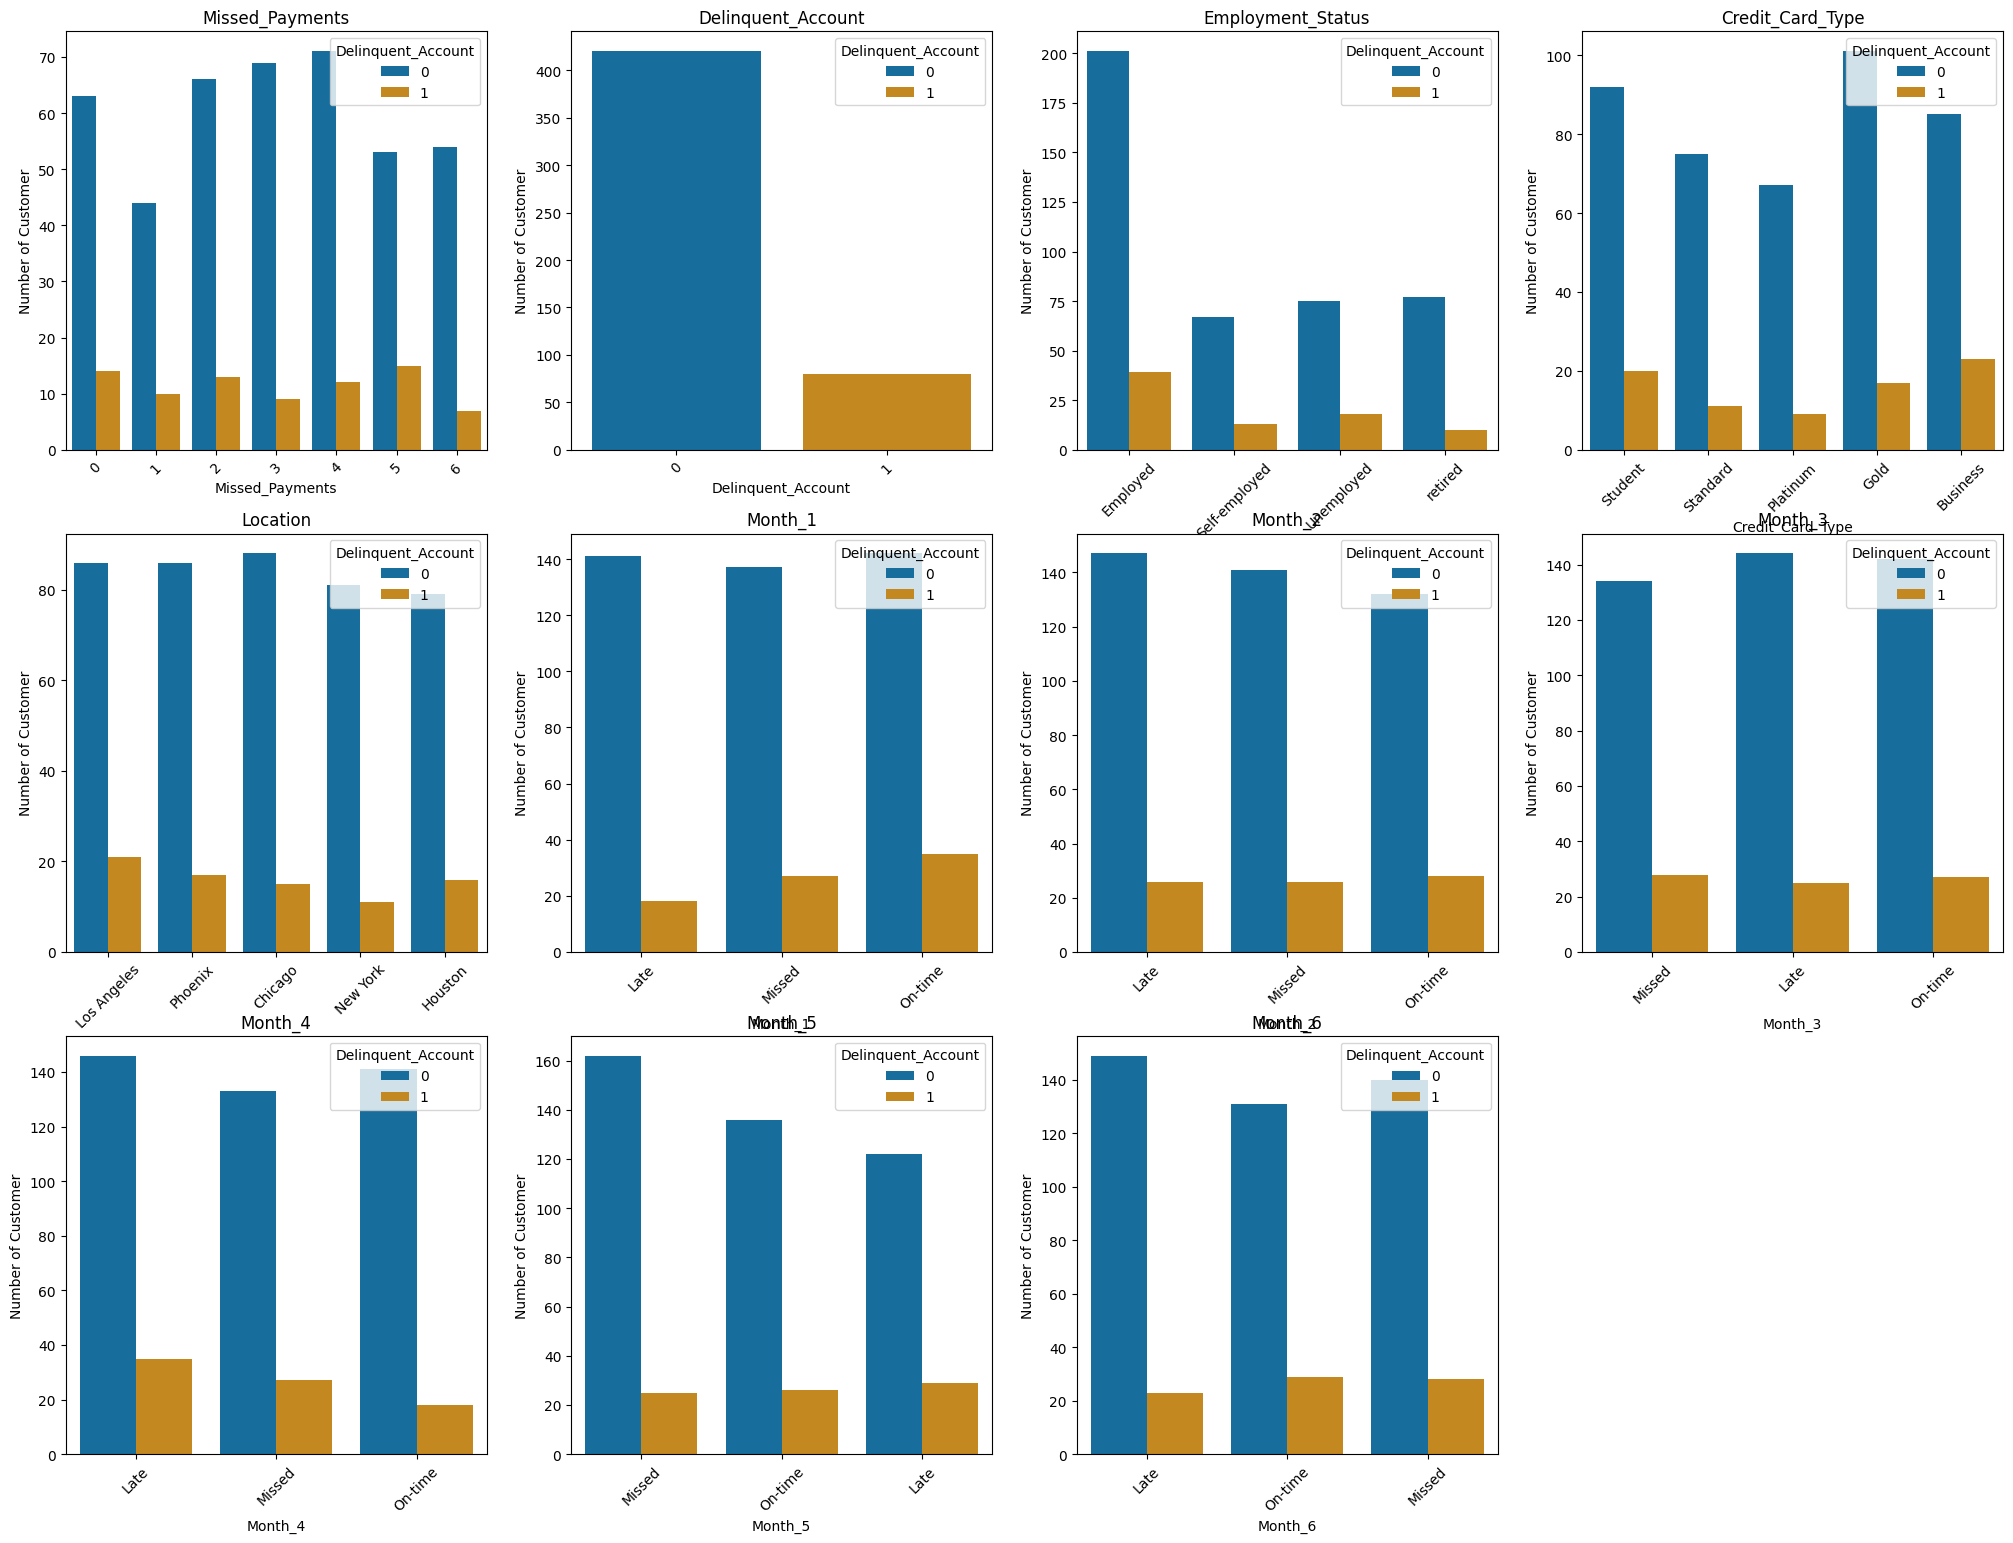

In [20]:
count=df[['Missed_Payments','Delinquent_Account','Employment_Status','Credit_Card_Type','Location','Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']]

plt.figure(figsize=(25,25))
plotno=1

for column in count:
    if plotno<12:
        plt.subplot(4,4,plotno)
        sns.countplot(x=count[column],palette='colorblind',data=df,hue='Delinquent_Account')
        plt.title(column)
        plt.ylabel("Number of Customer")
        plt.xticks(rotation=45)
        plotno+=1
plt.show()

<b>Observation

0 → Good standing (no delinquency)

1 → Delinquent (has missed or overdue payments)

(1) missing payment:<br>
most customer missed 2 to 4 payments highly.<br>
only one payment missed that customes are less.

(2) Delinquent Account:<br>
majority of not delinquent account(0).<br>
This column is target column to predict the risk.

(3) Employment Status:<br>
Unemployed customers are more than other.

(4) Credit card type: <br>
Most of the customer purchased Gold type of credit card.Less customers have platinum type of credit card. 

(5) Location:<br>
credit card distributed fairly across all cities,slighty fewer in New York.

(6) Month_1 to Month_6:<br>
There are count of on-site,late,missed payment of each month.<br>
Late payment ratio consistently high 

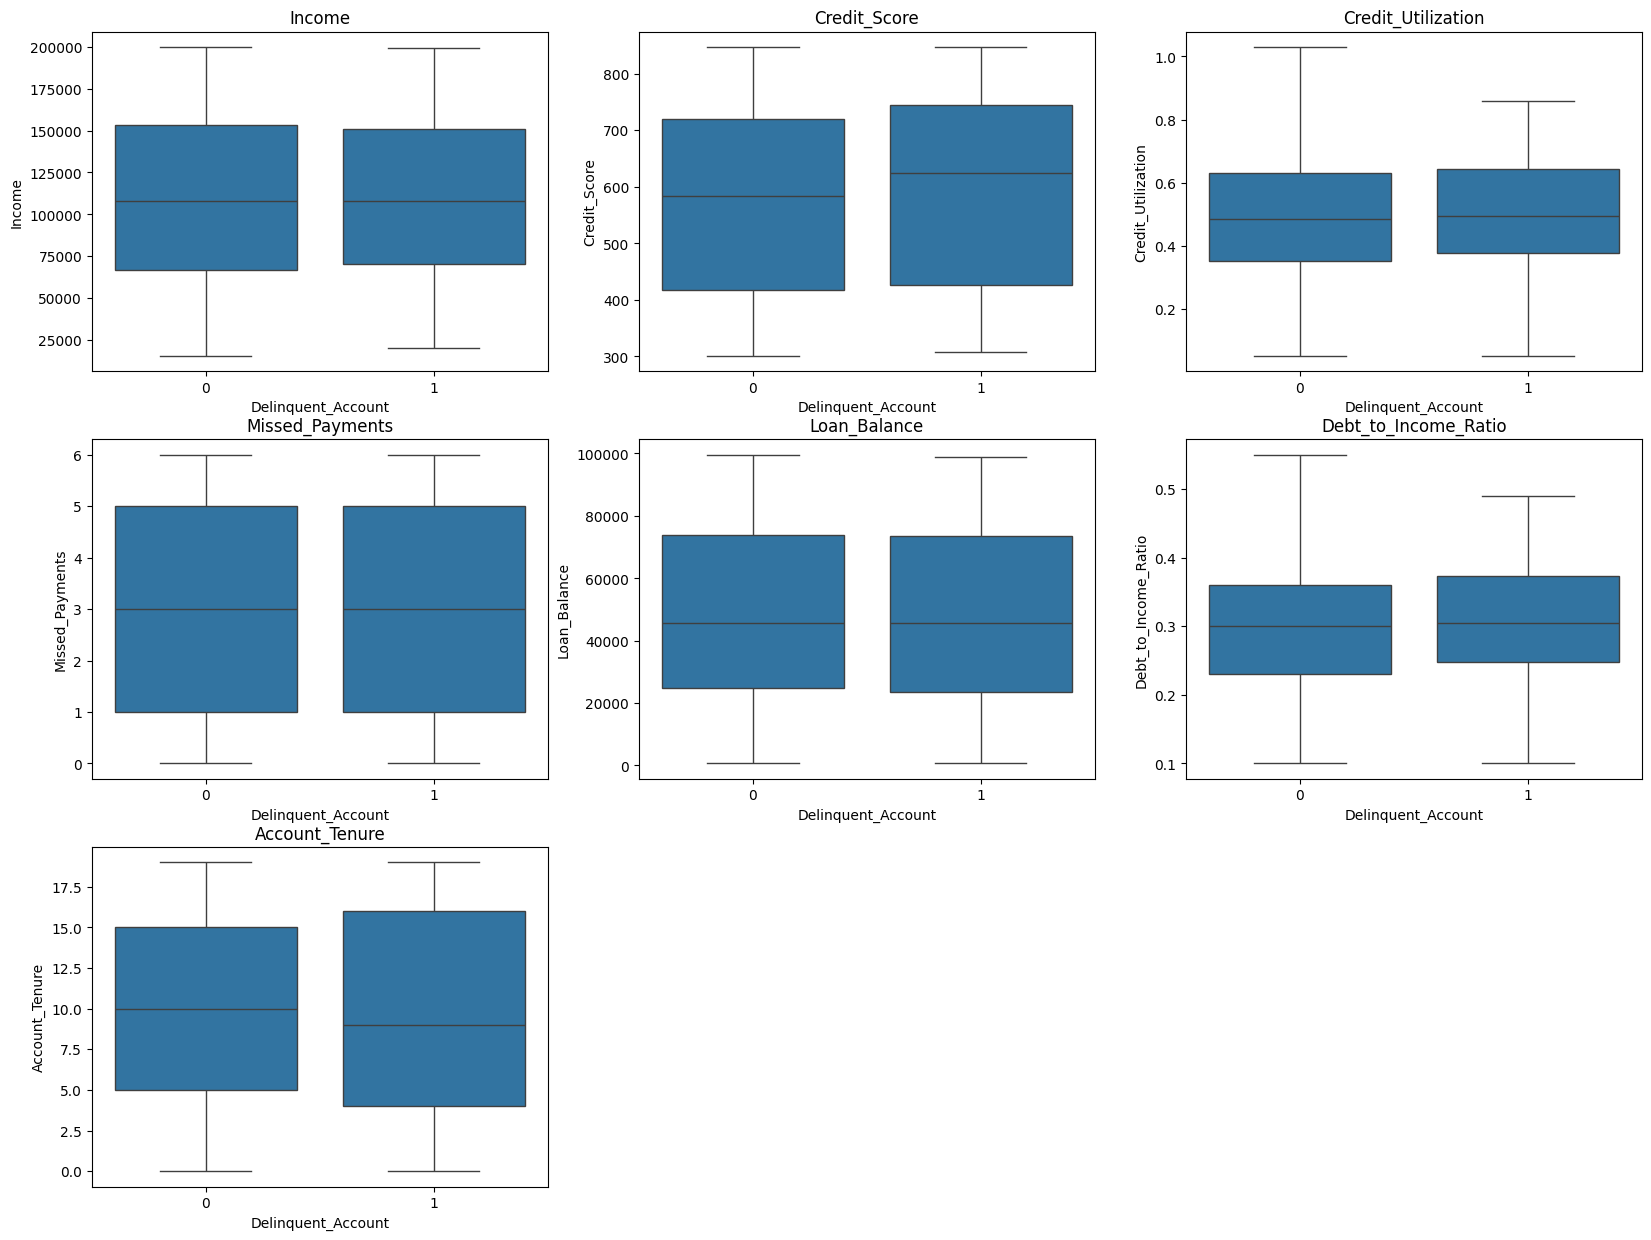

In [22]:
data=df[['Income','Credit_Score','Credit_Utilization','Missed_Payments','Loan_Balance','Debt_to_Income_Ratio','Account_Tenure']]
plt.figure(figsize=(20,15))
plotno=1
for col in data:
    plt.subplot(3,3,plotno)
    sns.boxplot(y=data[col],x='Delinquent_Account',data=df)
    plt.title(col)
    plotno+=1
plt.show()

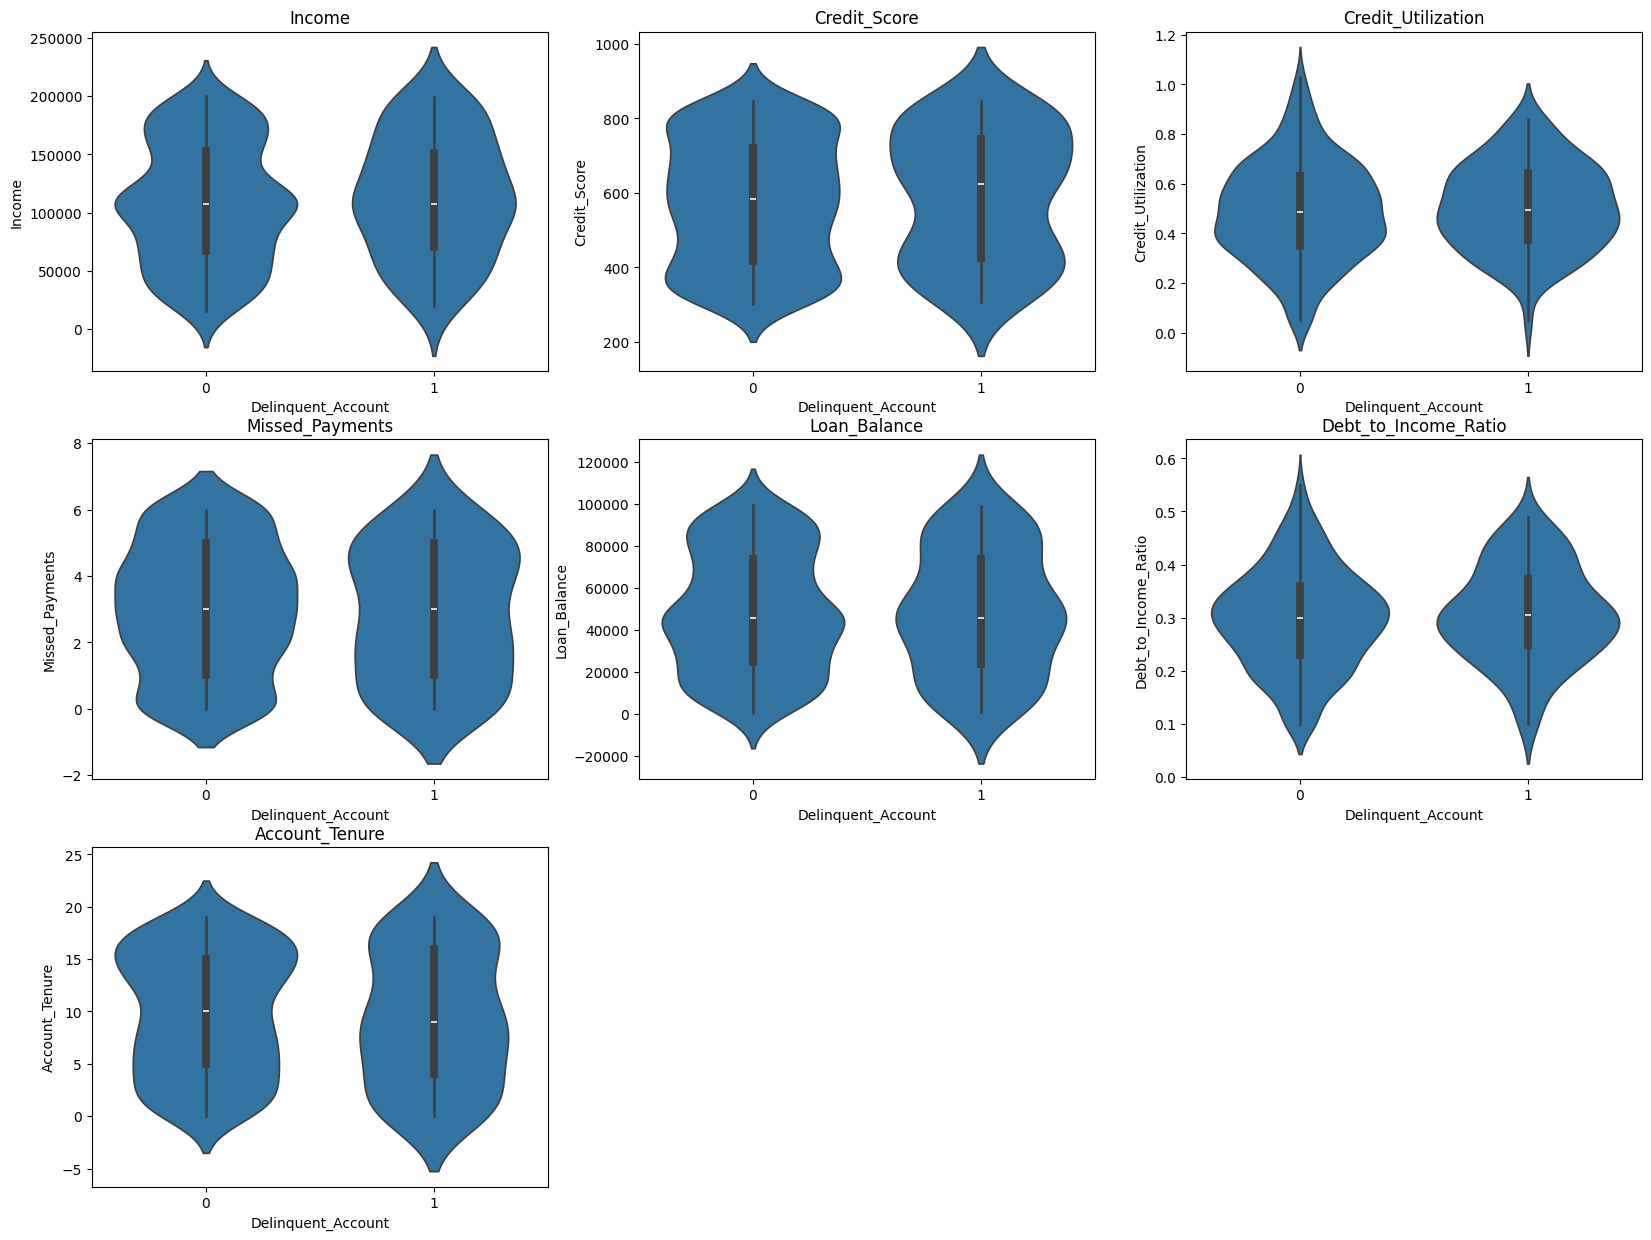

In [23]:
data=df[['Income','Credit_Score','Credit_Utilization','Missed_Payments','Loan_Balance','Debt_to_Income_Ratio','Account_Tenure']]
plt.figure(figsize=(20,15))
plotno=1
for col in data:
    plt.subplot(3,3,plotno)
    sns.violinplot(y=data[col],x='Delinquent_Account',data=df)
    plt.title(col)
    plotno+=1
plt.show()

Observation:<br>

Income → Similar, small difference.

Credit_Score → Non-delinquents usually have higher scores.

Credit_Utilization → Delinquents show slightly higher utilization.

Missed_Payments → Delinquents have more missed payments (strong signal).

Loan_Balance → Almost the same for both groups.

Debt_to_Income_Ratio → Slightly higher for delinquents.

Account_Tenure → No real difference.

<b>Data Preprocessing

Employment Status

In [25]:
df=pd.get_dummies(df,columns=['Employment_Status'],drop_first=True)

In [26]:
df.head(1)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,...,Location,Month_1,Month_2,Month_3,Month_4,Month_5,Month_6,Employment_Status_Self-employed,Employment_Status_Unemployed,Employment_Status_retired
0,CUST0001,56,165580.0,398.0,0.39,3,0,16310.0,0.32,18,...,Los Angeles,Late,Late,Missed,Late,Missed,Late,False,False,False


Credit card type

In [27]:
from sklearn.preprocessing import OrdinalEncoder

In [28]:
df['Credit_Card_Type'].unique()

array(['Student', 'Standard', 'Platinum', 'Gold', 'Business'],
      dtype=object)

In [29]:
card_order=[['Student','Standard','Platinum','Gold','Business']]
encoder=OrdinalEncoder(categories=card_order)
df['Credit_Card_Type']=encoder.fit_transform(df[['Credit_Card_Type']])

In [30]:
df['Credit_Card_Type'].unique()

array([0., 1., 2., 3., 4.])

Location

In [31]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

Month 1 to Month 6

In [32]:
df['Month_1'].unique()

array(['Late', 'Missed', 'On-time'], dtype=object)

In [33]:
mapping = {'On-time': 0, 'Late': 1, 'Missed': 2}
month = ['Month_1','Month_2','Month_3','Month_4','Month_5','Month_6']

for col in month:
    df[col] = df[col].map(mapping)


In [34]:
df['Month_1'].unique()

array([1, 2, 0])

In [35]:
df.head(1)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,...,Month_4,Month_5,Month_6,Employment_Status_Self-employed,Employment_Status_Unemployed,Employment_Status_retired,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,CUST0001,56,165580.0,398.0,0.39,3,0,16310.0,0.32,18,...,1,2,1,False,False,False,False,True,False,False


In [36]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


machine learning models or mathematical operations that require numeric values instead of boolean types.

In [37]:
df.head(1)

,Customer_ID,Age,Income,Credit_Score,Credit_Utilization,Missed_Payments,Delinquent_Account,Loan_Balance,Debt_to_Income_Ratio,Account_Tenure,...,Month_4,Month_5,Month_6,Employment_Status_Self-employed,Employment_Status_Unemployed,Employment_Status_retired,Location_Houston,Location_Los Angeles,Location_New York,Location_Phoenix
0,CUST0001,56,165580.0,398.0,0.39,3,0,16310.0,0.32,18,...,1,2,1,0,0,0,0,1,0,0


<b>Spliting data in features(X) and target(y)

In [38]:
X=df.drop(['Customer_ID','Delinquent_Account'],axis=1)

In [39]:
y=df['Delinquent_Account']

In [40]:
df['Delinquent_Account'].value_counts(normalize=True)


Delinquent_Account
0    0.84
1    0.16
Name: proportion, dtype: float64

<b>Train-Test Spliting

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE,RandomOverSampler
from xgboost import XGBClassifier
import numpy as np

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

stratify: Both train and test sets keep the **same class ratio** as the original → fair evaluation.


  Original dataset: 90% class 0, 10% class 1  
- After split (with stratify):
  - Train: 90% class 0, 10% class 1  
  - Test: 90% class 0, 10% class 1  

random_state: same split

<b>Problem:<br>
In imbalanced data,one class has very few samples.So model ignore small class.<br><br>
SMOTE:<br>
smote fixed this problem by using synthetic samples for smaller class.

In [43]:
# balanced data

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE :", np.bincount(y_train_res))


# Feature scaling (important for Logistic Regression)

scaler = StandardScaler()  
X_train_res_scaled = scaler.fit_transform(X_train_res)        
X_test_scaled = scaler.transform(X_test)


# Logistic Regression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_res_scaled, y_train_res)

y_pred_log = log_reg.predict(X_test_scaled)

print("\n Logistic Regression Report:")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]))


#  Random Forest

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test)

print("\n Random Forest Report:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))




Before SMOTE: [336  64]
After SMOTE : [336 336]

 Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82        84
           1       0.11      0.12      0.12        16

    accuracy                           0.70       100
   macro avg       0.47      0.47      0.47       100
weighted avg       0.71      0.70      0.71       100

ROC-AUC: 0.375

 Random Forest Report:
              precision    recall  f1-score   support

           0       0.83      0.94      0.88        84
           1       0.00      0.00      0.00        16

    accuracy                           0.79       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.70      0.79      0.74       100

ROC-AUC: 0.37648809523809523


<b>Insight:<br>

Step 1: after smote ,we have balanced data for both classes.<br><br>
Step 2: Scaling: fit_transform() learns the mean and standard deviation from the training set and scales it.<br>
        transform() applies the same scaling to the test set<br><br>
Step 3: Model apply

(1) Logistic regression:ROC-AUC value all most 0.35 ,so model is failing .<br>
(2) Random Forest: ROC-AUC value 0.38 ,it is also vary poor.

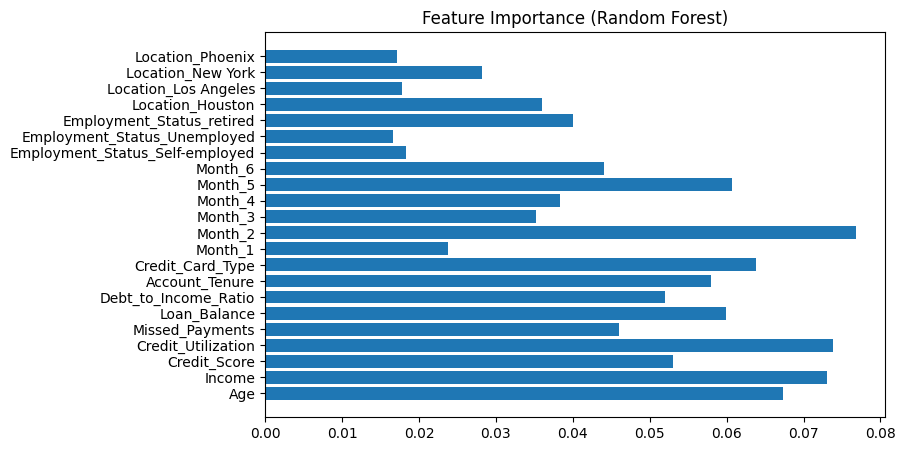

In [44]:
#  Feature Importance (Random Forest)

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

Importance features:<br>
Income<br>
Credit utilization<br>
Credit card type<br>
Missed payments<br>
Month 2 month 5<br>

Less importance:<br>
Location<br>
Employment Status

In [45]:
# Logistics regression

y_pred_log = log_reg.predict(X_test_scaled)   # predicted labels
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]  # probability of class 1 (delinquent)

print("Logistic Regression Predictions (first 10):", y_pred_log[:10])
print("Logistic Regression Probabilities (first 10):", y_proba_log[:10])


# Random Forest Predictions

y_pred_rf = rf.predict(X_test)   # predicted labels
y_proba_rf = rf.predict_proba(X_test)[:, 1]  # probability of class 1 (delinquent)

print("\nRandom Forest Predictions (first 10):", y_pred_rf[:10])
print("Random Forest Probabilities (first 10):", y_proba_rf[:10])

Logistic Regression Predictions (first 10): [1 0 0 0 0 0 0 0 0 0]
Logistic Regression Probabilities (first 10): [0.52118114 0.34354063 0.0788186  0.1184617  0.26545363 0.067134
 0.05571869 0.07474625 0.08594813 0.03227632]

Random Forest Predictions (first 10): [0 0 0 0 0 0 0 0 0 0]
Random Forest Probabilities (first 10): [0.315 0.28  0.33  0.205 0.255 0.135 0.12  0.225 0.245 0.12 ]


<b>Upsampling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_scaled, y_train)



print("Before upsampling:", y_train.value_counts())
print("After upsampling:", y_resampled.value_counts())


xgb_model = XGBClassifier(             # Extreme Gradiant Boosting
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss"
)

xgb_model.fit(X_resampled, y_resampled)


y_pred = xgb_model.predict(X_test_scaled)
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]


print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


Before upsampling: Delinquent_Account
0    336
1     64
Name: count, dtype: int64
After upsampling: Delinquent_Account
0    336
1    336
Name: count, dtype: int64

Confusion Matrix:
 [[79  5]
 [16  0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.94      0.88        84
           1       0.00      0.00      0.00        16

    accuracy                           0.79       100
   macro avg       0.42      0.47      0.44       100
weighted avg       0.70      0.79      0.74       100

ROC-AUC Score: 0.3430059523809524


<b>`Function for prediction`

In [47]:
# Function for prediction

def predict_new_data(model, scaler, encoder, new_data):
    # 1. Encode categorical features
    new_data_enc = pd.get_dummies(new_data, drop_first=False)
    
    # 2. Reindex to match training columns
    new_data_enc = new_data_enc.reindex(columns=encoder, fill_value=0)
    
    # 3. Scale numerical features
    new_data_scaled = scaler.transform(new_data_enc)
    
    # 4. Predict
    pred = model.predict(new_data_scaled)
    proba = model.predict_proba(new_data_scaled)[:, 1]
    
    return pred, proba

<b>Take different Cases 

In [48]:
# Test Case 1:

risky_profile = pd.DataFrame([{
    "Age": 59,
    "Income": 20000,
    "Credit_Score": 374,
    "Credit_Utilization": 0.32,
    "Missed_Payments": 1,
    "Loan_Balance": 82000,
    "Debt_to_Income_Ratio": 0.24,
    "Account_Tenure": 1,
    "Credit_Card_Type": 3,
    "Month_1": 1, "Month_2": 1, "Month_3": 0,
    "Month_4": 1, "Month_5": 0, "Month_6": 1,
    "Employment_Status": "Unemployed",
    "Location": "New York"
}])


# Test Case 2: 

good_profile = pd.DataFrame([{
    "Age": 45,
    "Income": 120000,
    "Credit_Score": 780,
    "Credit_Utilization": 0.15,
    "Missed_Payments": 0,
    "Loan_Balance": 5000,
    "Debt_to_Income_Ratio": 0.18,
    "Account_Tenure": 10,
    "Credit_Card_Type": 2,
    "Month_1": 0, "Month_2": 0, "Month_3": 0,
    "Month_4": 0, "Month_5": 0, "Month_6": 0,
    "Employment_Status": "Employed",
    "Location": "Los Angeles"
}])


# Run predictions

for label, data in [("Risky Profile", risky_profile), ("Good Profile", good_profile)]:
    pred, proba = predict_new_data(log_reg, scaler, X_train.columns, data)
    print(f"\n--- {label} ---")
    print("Prediction →", "non Delinquent " if pred[0] == 1 else "Delinquent ")
    print("Probability  →", round(proba[0], 2))



--- Risky Profile ---
Prediction → Delinquent 
Probability  → 0.46

--- Good Profile ---
Prediction → non Delinquent 
Probability  → 0.96


<b>`Logistic` model used 

In [49]:
# Test Case 3:
profile = pd.DataFrame([{
    "Age": 30,
    "Income": 5000,
    "Credit_Score": 220,
    "Credit_Utilization": 0.50,
    "Missed_Payments": 1,
    "Loan_Balance": 15000,
    "Debt_to_Income_Ratio": 0.45,
    "Account_Tenure": 2,
    "Credit_Card_Type": 2,
    "Month_1": 2, "Month_2": 2, "Month_3": 1,
    "Month_4": 1, "Month_5": 0, "Month_6": 3,
    "Employment_Status": "Unemployed",
    "Location": "Los Angeles"
}])


for label, data in [ ("Profile", profile)]:
    pred, proba = predict_new_data(log_reg, scaler, X_train.columns, data)
    print(f"\n--- {label} ---")
    print("Prediction →", "non Delinquent " if pred[0] == 1 else "Delinquent ")
    print("Probability  →", round(proba[0], 2))


--- Profile ---
Prediction → Delinquent 
Probability  → 0.09


<b> `XGB `model used

In [50]:
profile = pd.DataFrame([{
    "Age": 30,
    "Income": 5000,
    "Credit_Score": 220,
    "Credit_Utilization": 0.50,
    "Missed_Payments": 1,
    "Loan_Balance": 15000,
    "Debt_to_Income_Ratio": 0.45,
    "Account_Tenure": 2,
    "Credit_Card_Type": 2,
    "Month_1": 2, "Month_2": 2, "Month_3": 1,
    "Month_4": 1, "Month_5": 0, "Month_6": 3,
    "Employment_Status": "Unemployed",
    "Location": "Los Angeles"
}])


for label, data in [ ("Profile", profile)]:
    pred, proba = predict_new_data(xgb_model, scaler, X_train.columns, data)
    print(f"\n--- {label} ---")
    print("Prediction →", "non Delinquent " if pred[0] == 1 else "Delinquent ")
    print("Probability  →", round(proba[0], 2))


--- Profile ---
Prediction → Delinquent 
Probability  → 0.02


<b>`Random Forest` Model used


In [51]:
profile = pd.DataFrame([{
    "Age": 30,
    "Income": 5000,
    "Credit_Score": 220,
    "Credit_Utilization": 0.50,
    "Missed_Payments": 1,
    "Loan_Balance": 15000,
    "Debt_to_Income_Ratio": 0.45,
    "Account_Tenure": 2,
    "Credit_Card_Type": 2,
    "Month_1": 2, "Month_2": 2, "Month_3": 1,
    "Month_4": 1, "Month_5": 0, "Month_6": 3,
    "Employment_Status": "Unemployed",
    "Location": "Los Angeles"
}])


for label, data in [ ("Profile", profile)]:
    pred, proba = predict_new_data(rf, scaler, X_train.columns, data)
    print(f"\n--- {label} ---")
    print("Prediction →", "non Delinquent " if pred[0] == 1 else "Delinquent ")
    print("Probability  →", round(proba[0], 2))


--- Profile ---
Prediction → Delinquent 
Probability  → 0.26


In [52]:
profile = pd.DataFrame([{
    "Age": 60,
    "Income": 20000,
    "Credit_Score": 250,
    "Credit_Utilization": 0.70,
    "Missed_Payments": 3,
    "Loan_Balance": 15000,
    "Debt_to_Income_Ratio": 0.59,
    "Account_Tenure": 2,
    "Credit_Card_Type": 2,
    "Month_1": 2, "Month_2": 2, "Month_3": 1,
    "Month_4": 1, "Month_5": 0, "Month_6": 3,
    "Employment_Status": "Unemployed",
    "Location": "New York"
}])


for label, data in [ ("Profile", profile)]:
    pred, proba = predict_new_data(rf, scaler, X_train.columns, data)
    print(f"\n--- {label} ---")
    print("Prediction →", "non Delinquent " if pred[0] == 1 else "Delinquent ")
    print("Probability  →", round(proba[0], 2))


--- Profile ---
Prediction → Delinquent 
Probability  → 0.24


In [53]:
import joblib

`joblib` is used to save (dump) and load (load) ML models and preprocessing objects for reuse.

In [54]:
joblib.dump(log_reg, "log_reg_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns, "encoder.pkl")

['encoder.pkl']

In [55]:
joblib.dump(xgb_model, "xgb_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns, "encoder.pkl")

['encoder.pkl']

In [56]:
joblib.dump(rf, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(X_train.columns, "encoder.pkl")

['encoder.pkl']